In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, auc

In [2]:
data = load_breast_cancer()

In [3]:
X = data.data
y = data.target

In [4]:
X.shape

(569, 30)

In [5]:
y.shape

(569,)

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size =0.2,random_state=42, stratify = y)

# strstify = Split the data while maintaining the class ratio.

In [9]:
clf = LogisticRegression(max_iter =10000)
clf.fit(X_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

In [12]:
# Normal Classification prediction
y_pred = clf.predict(X_test)
print("Accuracy_score:" , accuracy_score(y_test,y_pred))
print("\n Confusion Matrix")
pd.DataFrame(confusion_matrix(y_test,y_pred))

Accuracy_score: 0.9649122807017544

 Confusion Matrix


,0,1
0,39,3
1,1,71


In [13]:
#  Get Probability
y_prob = clf.predict_proba(X_test)[:,1]
print("\n first 10 predicted probabilities:")
print(y_prob[:10])


 first 10 predicted probabilities:
[3.41657281e-11 9.99964828e-01 5.06713510e-02 6.04482489e-01
 2.04525261e-09 9.82507208e-01 9.99970759e-01 1.00712838e-05
 4.92340221e-05 1.45291498e-10]


In [14]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [15]:
# Calculate AUC
roc_auc = roc_auc_score(y_test,y_pred)
print("\n AUC:", roc_auc)


 AUC: 0.9573412698412699


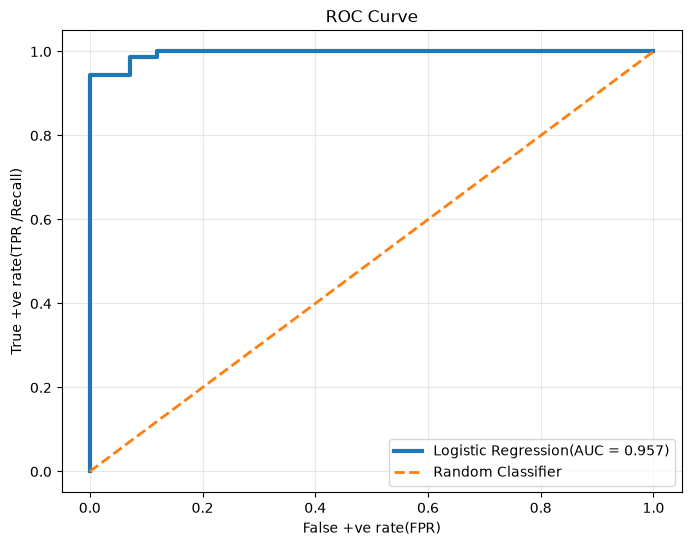

In [17]:
# plot ROC curve

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,linewidth=3, label=f"Logistic Regression(AUC = {roc_auc:.3f})")

# random classifier
plt.plot([0,1],[0,1],linestyle="--", linewidth=2, label="Random Classifier")

plt.xlabel("False +ve rate(FPR)")
plt.ylabel("True +ve rate(TPR /Recall)")

plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()